# Module 4 — Pricing & Discount Strategy
# Owner: Member B

# Covers:
  1. Discount distribution
  2. Revenue by discount band
 3. Margin impact of discounting
    4. Discount vs quantity sold (correlation + elasticity regression)
 5. Over-discounted products & customers
# Methods: correlation, OLS regression, hypothesis tests, margin comparison,
#          campaign vs organic (promotion) analysis


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from scipy import stats
import json
import os
import warnings
warnings.filterwarnings('ignore')

In [38]:
# ---- style ----
NAVY, BLUE, AMBER, SLATE, RED = '#1E3A5F', '#2563EB', '#F59E0B', '#718096', '#DC2626'
plt.rcParams.update({
    'figure.dpi': 100, 'font.size': 14, 'axes.titlesize': 18,
    'axes.labelsize': 15, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 12
})
FIG_SIZE = (12, 6.75)

EXPORT_DIR = '../exports/module4'
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_json(obj, name):
    path = f'{EXPORT_DIR}/{name}'
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'Saved {path}')

def save_fig(fig, name):
    path = f'{EXPORT_DIR}/{name}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved {path}')

In [39]:
# ---- load ----
df = pd.read_csv('/content/master_sales.csv', low_memory=False)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [40]:
# Effective price & basic fields
df['effective_price'] = df['unit_price'] * (1 - df['discount_percentage'] / 100)

In [41]:
# Ensure discount_band exists (adjust bins if your pipeline already creates it)
if 'discount_band' not in df.columns:
    df['discount_band'] = pd.cut(
        df['discount_percentage'],
        bins=[-0.01, 0, 5, 10, 15, 20, 100],
        labels=['0%', '1-5%', '6-10%', '11-15%', '16-20%', '20%+']
    )

In [42]:
# Margin: prefer existing column; else derive if possible
if 'margin_percentage_tx' not in df.columns:
    if 'cost' in df.columns:
        df['margin_percentage_tx'] = (
            (df['net_revenue'] - df['cost'] * df['quantity']) / df['net_revenue'].replace(0, np.nan) * 100
        )
    else:
        # fallback: margin proxy from standard vs effective price
        df['margin_percentage_tx'] = (
            (df['standard_price'] - df['effective_price']) / df['standard_price'].replace(0, np.nan) * 100
        )

print('Shape:', df.shape)
print('Columns sample:', list(df.columns)[:15])

Shape: (50000, 41)
Columns sample: ['transaction_id', 'transaction_date', 'customer_id', 'product_id', 'branch_id', 'channel', 'quantity', 'unit_price', 'discount_percentage', 'gross_revenue', 'net_revenue', 'cost', 'gross_margin', 'payment_status', 'campaign_id']


In [43]:
# 5.1 — Baseline: average discount & price variance
# =============================================================================
discount_kpis = {
    'avg_discount_pct': round(df['discount_percentage'].mean(), 2),
    'median_discount_pct': round(df['discount_percentage'].median(), 2),
    'pct_transactions_discounted': round((df['discount_percentage'] > 0).mean() * 100, 2),
    'avg_effective_price': round(df['effective_price'].mean(), 2),
    'effective_price_std': round(df['effective_price'].std(), 2),
    'effective_price_variance': round(df['effective_price'].var(), 2),
    'avg_standard_price': round(df['standard_price'].mean(), 2),
    'avg_margin_pct': round(df['margin_percentage_tx'].mean(), 2),
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(discount_kpis, 'discount_kpis.json')
print('\n=== 5.1 Baseline KPIs ===')
for k, v in discount_kpis.items():
    print(f'  {k}: {v}')

Saved ../exports/module4/discount_kpis.json

=== 5.1 Baseline KPIs ===
  avg_discount_pct: 10.45
  median_discount_pct: 10.0
  pct_transactions_discounted: 77.18
  avg_effective_price: 113.21
  effective_price_std: 138.79
  effective_price_variance: 19261.73
  avg_standard_price: 126.65
  avg_margin_pct: 28.7
  generated_at: 2026-07-31T11:19:03.128290+00:00


Saved ../exports/module4/discount_dist.json
Saved ../exports/module4/discount_distribution.png


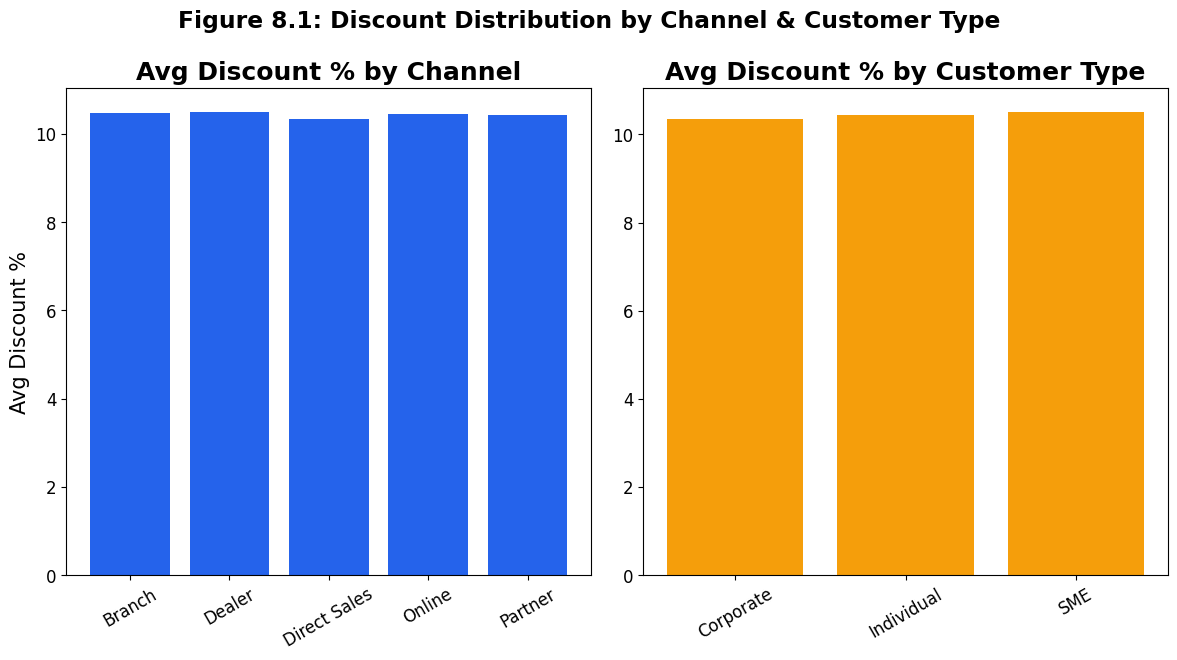

In [44]:
# =============================================================================
# 5.2 — Discount distribution (by channel, customer type, band)
# =============================================================================
discount_by_channel = (
    df.groupby('channel')['discount_percentage']
    .agg(['mean', 'median', 'count']).round(2)
)
discount_by_custtype = (
    df.groupby('customer_type')['discount_percentage']
    .agg(['mean', 'median', 'count']).round(2)
)
discount_band_counts = df['discount_band'].value_counts().sort_index()

discount_dist = {
    'by_channel': discount_by_channel.reset_index().to_dict(orient='records'),
    'by_customer_type': discount_by_custtype.reset_index().to_dict(orient='records'),
    'discount_band_distribution': discount_band_counts.to_dict(),
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(discount_dist, 'discount_dist.json')
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].bar(discount_by_channel.index.astype(str), discount_by_channel['mean'], color=BLUE)
axes[0].set_title('Avg Discount % by Channel', fontweight='bold')
axes[0].set_ylabel('Avg Discount %')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(discount_by_custtype.index.astype(str), discount_by_custtype['mean'], color=AMBER)
axes[1].set_title('Avg Discount % by Customer Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Figure 8.1: Discount Distribution by Channel & Customer Type', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'discount_distribution.png')
plt.show()

Saved ../exports/module4/revenue_by_discount_band.json

=== Revenue by Discount Band ===
               transactions  total_net_revenue  avg_net_revenue  \
discount_band                                                     
0%                    11408         4520159.36           396.23   
1-5%                   9778         3779474.54           386.53   
11-15%                 8153         2814601.34           345.22   
16-20%                 6140         2023482.24           329.56   
20%+                   5423         1614675.05           297.75   
6-10%                  9098         3361409.11           369.47   

               total_quantity  avg_quantity  avg_discount_pct  avg_margin_pct  \
discount_band                                                                   
0%                      36359          3.19              0.00           36.83   
1-5%                    31506          3.22              5.00           33.61   
11-15%                  25838          3.17       

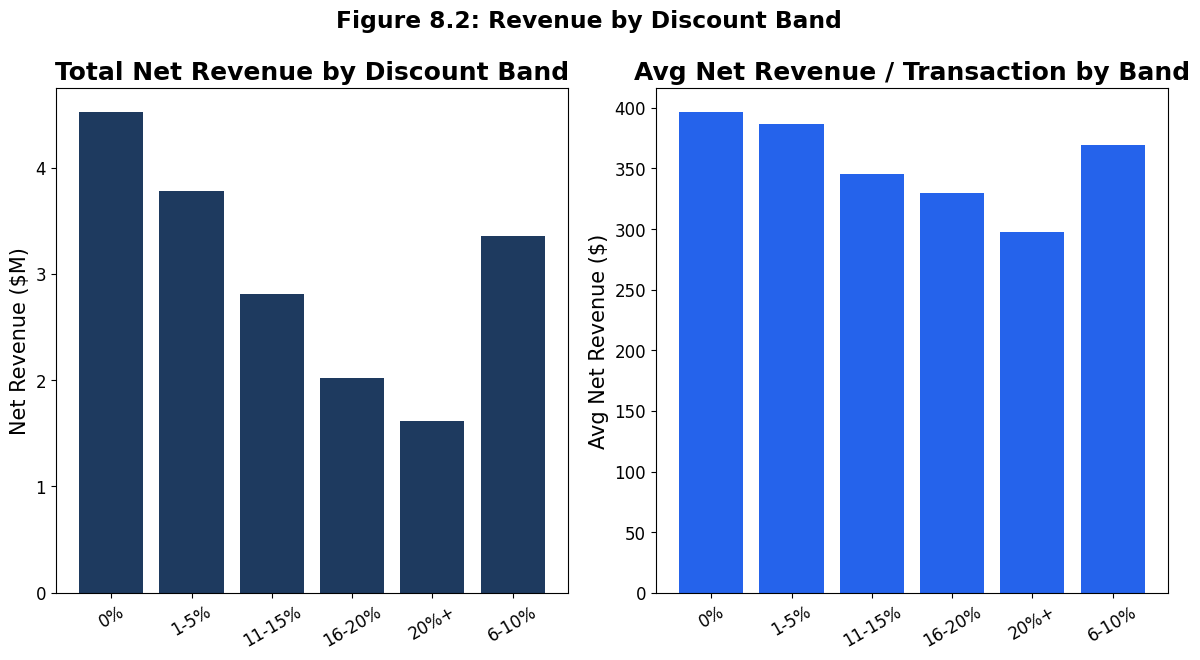

In [45]:
# 5.2b — REQUIRED: Revenue by discount band
# =============================================================================
rev_by_band = df.groupby('discount_band', observed=True).agg(
    transactions=('transaction_id', 'count'),
    total_net_revenue=('net_revenue', 'sum'),
    avg_net_revenue=('net_revenue', 'mean'),
    total_quantity=('quantity', 'sum'),
    avg_quantity=('quantity', 'mean'),
    avg_discount_pct=('discount_percentage', 'mean'),
    avg_margin_pct=('margin_percentage_tx', 'mean')
).round(2)

# Share of total revenue
rev_by_band['revenue_share_pct'] = (
    rev_by_band['total_net_revenue'] / rev_by_band['total_net_revenue'].sum() * 100
).round(2)

save_json(
    {'revenue_by_discount_band': rev_by_band.reset_index().to_dict(orient='records'),
     'generated_at': pd.Timestamp.now('UTC').isoformat()},
    'revenue_by_discount_band.json'
)

print('\n=== Revenue by Discount Band ===')
print(rev_by_band)
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].bar(rev_by_band.index.astype(str), rev_by_band['total_net_revenue'] / 1e6, color=NAVY)
axes[0].set_title('Total Net Revenue by Discount Band', fontweight='bold')
axes[0].set_ylabel('Net Revenue ($M)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(rev_by_band.index.astype(str), rev_by_band['avg_net_revenue'], color=BLUE)
axes[1].set_title('Avg Net Revenue / Transaction by Band', fontweight='bold')
axes[1].set_ylabel('Avg Net Revenue ($)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Figure 8.2: Revenue by Discount Band', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'revenue_by_discount_band.png')
plt.show()

Saved ../exports/module4/margin_impact.json

=== Margin Impact ===
Corr(discount, margin): -0.5529
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  38.0068      0.083    459.101      0.000      37.845      38.169
discount_percentage    -0.8906      0.006   -148.369      0.000      -0.902      -0.879
               avg_margin_pct  median_margin_pct  avg_discount_pct  \
discount_band                                                        
0%                      36.83              36.92              0.00   
1-5%                    33.61              33.66              5.00   
11-15%                  26.35              26.35             14.29   
16-20%                  22.09              22.05             19.05   
20%+                    11.79              13.46             28.08   
6-10%                   29.89              29.95           

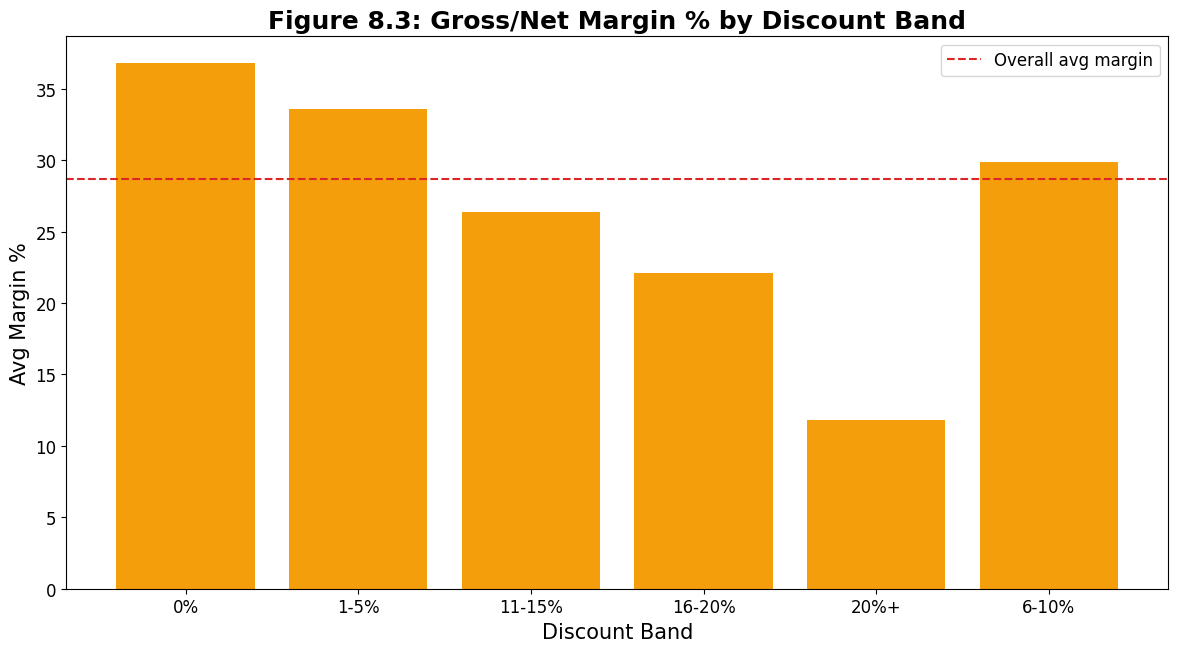

In [46]:
# 5.3 — REQUIRED: Margin impact of discounting
# =============================================================================
margin_by_band = df.groupby('discount_band', observed=True).agg(
    avg_margin_pct=('margin_percentage_tx', 'mean'),
    median_margin_pct=('margin_percentage_tx', 'median'),
    avg_discount_pct=('discount_percentage', 'mean'),
    transactions=('transaction_id', 'count')
).round(2)

# Correlation: discount depth vs margin
corr_discount_margin = df['discount_percentage'].corr(df['margin_percentage_tx'])

# Simple linear regression: margin ~ discount
m = df[['discount_percentage', 'margin_percentage_tx']].dropna()
X_m = sm.add_constant(m['discount_percentage'])
model_margin = sm.OLS(m['margin_percentage_tx'], X_m).fit()

margin_impact = {
    'corr_discount_vs_margin': round(corr_discount_margin, 4),
    'ols_coef_discount_on_margin': round(float(model_margin.params['discount_percentage']), 4),
    'ols_pvalue': round(float(model_margin.pvalues['discount_percentage']), 4),
    'margin_by_band': margin_by_band.reset_index().to_dict(orient='records'),
    'interpretation': (
        'Negative relationship expected: deeper discounts reduce margin. '
        f'Corr={corr_discount_margin:.3f}; OLS slope={model_margin.params["discount_percentage"]:.3f} pp margin per 1pp discount.'
    ),
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(margin_impact, 'margin_impact.json')

print('\n=== Margin Impact ===')
print(f'Corr(discount, margin): {corr_discount_margin:.4f}')
print(model_margin.summary().tables[1])
print(margin_by_band)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(margin_by_band.index.astype(str), margin_by_band['avg_margin_pct'], color=AMBER)
ax.set_xlabel('Discount Band')
ax.set_ylabel('Avg Margin %')
ax.set_title('Figure 8.3: Gross/Net Margin % by Discount Band', fontweight='bold')
ax.axhline(df['margin_percentage_tx'].mean(), color=RED, linestyle='--', label='Overall avg margin')
ax.legend()
plt.tight_layout()
save_fig(fig, 'margin_by_discount_band.png')
plt.show()

In [47]:
# 5.4 — Discount vs quantity (correlation + elasticity regression)
# =============================================================================
corr_discount_qty = df['discount_percentage'].corr(df['quantity'])

# Log-log elasticity: log(Q) = a + b * log(P_effective)
df_clean = df[(df['effective_price'] > 0) & (df['quantity'] > 0)].copy()
df_clean['log_qty'] = np.log(df_clean['quantity'])
df_clean['log_price'] = np.log(df_clean['effective_price'])

X = sm.add_constant(df_clean['log_price'])
model_elas = sm.OLS(df_clean['log_qty'], X).fit()
elasticity = float(model_elas.params['log_price'])
elas_pval = float(model_elas.pvalues['log_price'])

elasticity_result = {
    'corr_discount_vs_quantity': round(corr_discount_qty, 4),
    'elasticity_coef': round(elasticity, 4),
    'elasticity_pvalue': round(elas_pval, 4),
    'r_squared': round(float(model_elas.rsquared), 4),
    'interpretation': (
        'Inelastic / not significant' if elas_pval > 0.05 or abs(elasticity) < 0.1
        else ('Elastic' if elasticity < -1 else 'Inelastic')
    ),
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(elasticity_result, 'elasticity_model.json')

print('\n=== Discount vs Quantity / Elasticity ===')
print(f'Corr(discount, quantity): {corr_discount_qty:.4f}')
print(model_elas.summary())

Saved ../exports/module4/elasticity_model.json

=== Discount vs Quantity / Elasticity ===
Corr(discount, quantity): -0.0020
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7486
Date:                Fri, 31 Jul 2026   Prob (F-statistic):              0.387
Time:                        11:19:06   Log-Likelihood:                -37037.
No. Observations:               50000   AIC:                         7.408e+04
Df Residuals:                   49998   BIC:                         7.410e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------


Quantity by discount band:
               mean  median    sum  count
discount_band                            
0%             3.19     3.0  36359  11408
1-5%           3.22     3.0  31506   9778
11-15%         3.17     3.0  25838   8153
16-20%         3.18     3.0  19517   6140
20%+           3.20     3.0  17373   5423
6-10%          3.18     3.0  28959   9098
Saved ../exports/module4/discount_vs_quantity.png


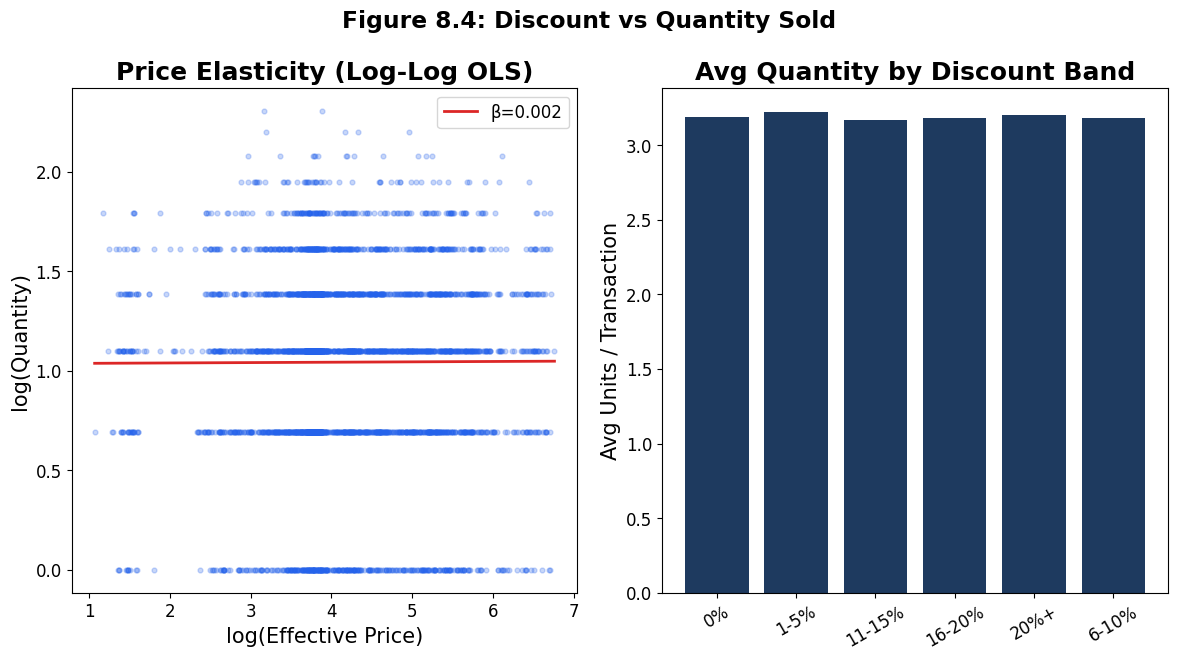

In [48]:
# Quantity by discount band
qty_by_band = df.groupby('discount_band', observed=True)['quantity'].agg(['mean', 'median', 'sum', 'count']).round(2)
print('\nQuantity by discount band:')
print(qty_by_band)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
# scatter sample
sample = df_clean.sample(min(3000, len(df_clean)), random_state=42)
axes[0].scatter(sample['log_price'], sample['log_qty'], alpha=0.25, s=12, color=BLUE)
# fitted line
x_line = np.linspace(sample['log_price'].min(), sample['log_price'].max(), 100)
axes[0].plot(x_line, model_elas.params['const'] + model_elas.params['log_price'] * x_line,
             color=RED, lw=2, label=f'β={elasticity:.3f}')
axes[0].set_xlabel('log(Effective Price)')
axes[0].set_ylabel('log(Quantity)')
axes[0].set_title('Price Elasticity (Log-Log OLS)', fontweight='bold')
axes[0].legend()

axes[1].bar(qty_by_band.index.astype(str), qty_by_band['mean'], color=NAVY)
axes[1].set_title('Avg Quantity by Discount Band', fontweight='bold')
axes[1].set_ylabel('Avg Units / Transaction')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Figure 8.4: Discount vs Quantity Sold', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'discount_vs_quantity.png')
plt.show()

In [49]:
# 5.4b — Hypothesis tests: does deeper discount increase quantity / reduce margin?
# =============================================================================
# Split: low discount (<= median) vs high discount (> median)
med = df['discount_percentage'].median()
low = df[df['discount_percentage'] <= med]['quantity']
high = df[df['discount_percentage'] > med]['quantity']
t_qty, p_qty = stats.ttest_ind(high, low, equal_var=False)

low_m = df[df['discount_percentage'] <= med]['margin_percentage_tx'].dropna()
high_m = df[df['discount_percentage'] > med]['margin_percentage_tx'].dropna()
t_mgn, p_mgn = stats.ttest_ind(high_m, low_m, equal_var=False)

In [50]:
# ANOVA: quantity across discount bands
bands = [g['quantity'].values for _, g in df.groupby('discount_band', observed=True)]
f_qty, p_anova_qty = stats.f_oneway(*bands) if len(bands) > 1 else (np.nan, np.nan)

hypothesis_tests = {
    'median_discount_split': float(med),
    'ttest_quantity_high_vs_low_discount': {
        't_stat': round(float(t_qty), 4),
        'p_value': round(float(p_qty), 4),
        'mean_qty_low_discount': round(float(low.mean()), 3),
        'mean_qty_high_discount': round(float(high.mean()), 3),
        'conclusion': 'No significant volume lift from deeper discounts'
                     if p_qty > 0.05 else 'Significant difference in quantity'
    },
    'ttest_margin_high_vs_low_discount': {
        't_stat': round(float(t_mgn), 4),
        'p_value': round(float(p_mgn), 4),
        'mean_margin_low_discount': round(float(low_m.mean()), 3),
        'mean_margin_high_discount': round(float(high_m.mean()), 3),
        'conclusion': 'Deeper discounts significantly reduce margin'
                     if p_mgn < 0.05 and high_m.mean() < low_m.mean()
                     else 'No clear margin reduction / check direction'
    },
    'anova_quantity_across_bands': {
        'f_stat': round(float(f_qty), 4) if pd.notna(f_qty) else None,
        'p_value': round(float(p_anova_qty), 4) if pd.notna(p_anova_qty) else None
    },
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(hypothesis_tests, 'hypothesis_tests.json')
print('\n=== Hypothesis Tests ===')
print(json.dumps(hypothesis_tests, indent=2))

Saved ../exports/module4/hypothesis_tests.json

=== Hypothesis Tests ===
{
  "median_discount_split": 10.0,
  "ttest_quantity_high_vs_low_discount": {
    "t_stat": -1.1523,
    "p_value": 0.2492,
    "mean_qty_low_discount": 3.197,
    "mean_qty_high_discount": 3.182,
    "conclusion": "No significant volume lift from deeper discounts"
  },
  "ttest_margin_high_vs_low_discount": {
    "t_stat": -99.6508,
    "p_value": 0.0,
    "mean_margin_low_discount": 33.703,
    "mean_margin_high_discount": 21.019,
    "conclusion": "Deeper discounts significantly reduce margin"
  },
  "anova_quantity_across_bands": {
    "f_stat": 1.4574,
    "p_value": 0.2002
  },
  "generated_at": "2026-07-31T11:19:07.859663+00:00"
}


In [51]:
# 5.5 — Revenue erosion from excessive discounting
# =============================================================================
POLICY_THRESHOLD = 20.0
excessive = df[df['discount_percentage'] > POLICY_THRESHOLD].copy()
excessive['revenue_at_list'] = excessive['quantity'] * excessive['unit_price']
# erosion = list revenue - actual net revenue (money given up)
excessive['erosion'] = excessive['revenue_at_list'] - excessive['net_revenue']

total_erosion = excessive['erosion'].sum()
total_net = df['net_revenue'].sum()
erosion_by_category = excessive.groupby('category')['erosion'].sum().sort_values(ascending=False).round(2)

erosion_summary = {
    'policy_threshold_pct': POLICY_THRESHOLD,
    'transactions_over_threshold': int(len(excessive)),
    'pct_of_transactions_over_threshold': round(len(excessive) / len(df) * 100, 2),
    'total_revenue_erosion': round(float(total_erosion), 2),
    'erosion_as_pct_of_total_net_revenue': round(float(total_erosion / total_net * 100), 2),
    'erosion_by_category': erosion_by_category.to_dict(),
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}
save_json(erosion_summary, 'erosion_summary.json')

Saved ../exports/module4/erosion_summary.json



Erosion from discounts > 20.0%: $633,668 (3.5% of net revenue)
Saved ../exports/module4/erosion_by_category.png


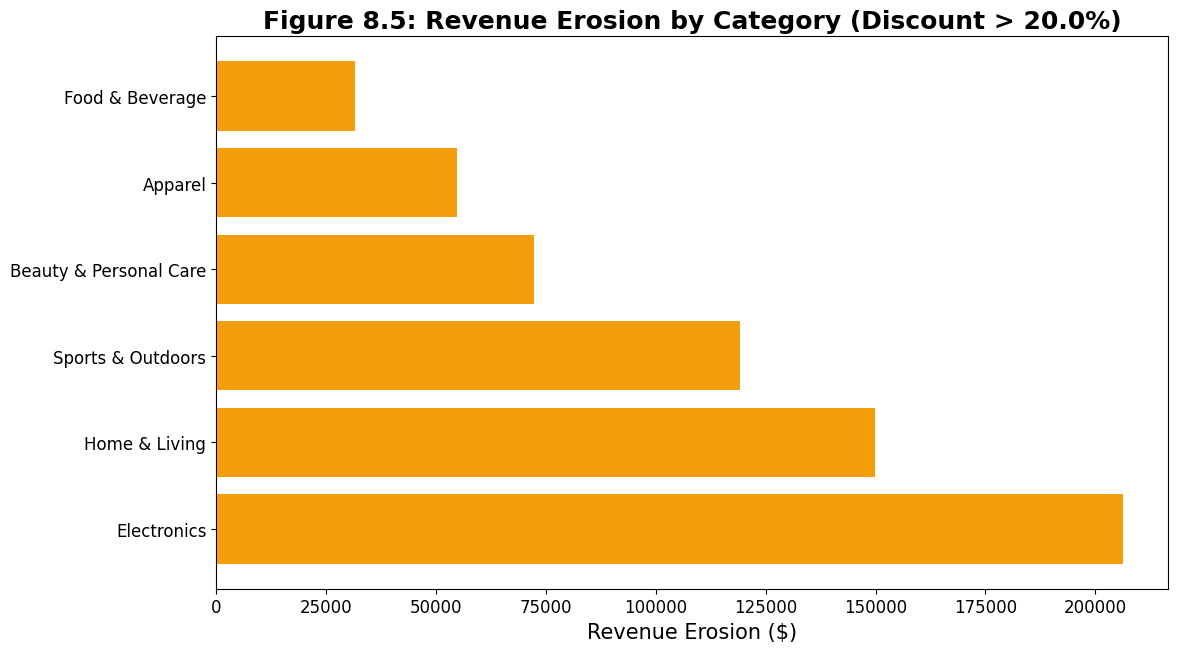

In [52]:
print(f"\nErosion from discounts > {POLICY_THRESHOLD}%: ${total_erosion:,.0f} "
      f"({erosion_summary['erosion_as_pct_of_total_net_revenue']}% of net revenue)")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.barh(erosion_by_category.index.astype(str), erosion_by_category.values, color=AMBER)
ax.set_xlabel('Revenue Erosion ($)')
ax.set_title(f'Figure 8.5: Revenue Erosion by Category (Discount > {POLICY_THRESHOLD}%)', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'erosion_by_category.png')
plt.show()

In [53]:
# 5.5b — REQUIRED: Over-discounted PRODUCTS
# =============================================================================
# Product key: prefer product_id / sku / product_name
prod_col = next((c for c in ['product_id', 'sku', 'product_name', 'product'] if c in df.columns), None)
if prod_col is None:
    # fall back to category x something coarse
    prod_col = 'category'
    print('WARN: no product id column; using category as product grain')

product_stats = df.groupby(prod_col).agg(
    transactions=('transaction_id', 'count'),
    avg_discount_pct=('discount_percentage', 'mean'),
    avg_margin_pct=('margin_percentage_tx', 'mean'),
    total_net_revenue=('net_revenue', 'sum'),
    avg_quantity=('quantity', 'mean'),
    pct_txns_over_20=('discount_percentage', lambda s: (s > 20).mean() * 100)
).round(2)

In [54]:
# Over-discounted products: high discount AND below-median margin (and enough volume)
margin_med = product_stats['avg_margin_pct'].median()
over_disc_products = product_stats[
    (product_stats['avg_discount_pct'] > 15) &
    (product_stats['avg_margin_pct'] < margin_med) &
    (product_stats['transactions'] >= 20)
].sort_values(['avg_discount_pct', 'avg_margin_pct'], ascending=[False, True])

save_json({
    'product_grain': prod_col,
    'n_over_discounted_products': int(len(over_disc_products)),
    'top_over_discounted_products': over_disc_products.head(25).reset_index().to_dict(orient='records'),
    'rule': 'avg_discount > 15% AND avg_margin < median AND transactions >= 20',
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}, 'over_discounted_products.json')

print(f'\n=== Over-discounted products (n={len(over_disc_products)}) ===')
print(over_disc_products.head(15))

Saved ../exports/module4/over_discounted_products.json

=== Over-discounted products (n=0) ===
Empty DataFrame
Columns: [transactions, avg_discount_pct, avg_margin_pct, total_net_revenue, avg_quantity, pct_txns_over_20]
Index: []


In [55]:
# 5.5c — REQUIRED: Over-discounted CUSTOMERS
# =============================================================================
cust_stats = df.groupby('customer_id').agg(
    orders=('transaction_id', 'nunique'),
    avg_discount_pct=('discount_percentage', 'mean'),
    avg_margin_pct=('margin_percentage_tx', 'mean'),
    total_net_revenue=('net_revenue', 'sum'),
    avg_quantity=('quantity', 'mean'),
    pct_txns_over_20=('discount_percentage', lambda s: (s > 20).mean() * 100)
).round(2)

cust_margin_med = cust_stats['avg_margin_pct'].median()
over_disc_customers = cust_stats[
    (cust_stats['avg_discount_pct'] > 15) &
    (cust_stats['avg_margin_pct'] < cust_margin_med) &
    (cust_stats['orders'] >= 3)
].sort_values(['avg_discount_pct', 'total_net_revenue'], ascending=[False, False])

save_json({
    'n_over_discounted_customers': int(len(over_disc_customers)),
    'top_over_discounted_customers': over_disc_customers.head(25).reset_index().to_dict(orient='records'),
    'rule': 'avg_discount > 15% AND avg_margin < median AND orders >= 3',
    'generated_at': pd.Timestamp.now('UTC').isoformat()
}, 'over_discounted_customers.json')

print(f'\n=== Over-discounted customers (n={len(over_disc_customers)}) ===')
print(over_disc_customers.head(15))

Saved ../exports/module4/over_discounted_customers.json

=== Over-discounted customers (n=24) ===
             orders  avg_discount_pct  avg_margin_pct  total_net_revenue  \
customer_id                                                                
C01838           16             19.29           16.50            8589.79   
C01682           12             18.19           20.52            4182.33   
C00642           29             18.06           19.57            7981.50   
C00784           17             17.09           24.52            5428.81   
C01600            8             16.99           18.31            2379.68   
C00163           25             16.59           20.98            8727.81   
C01485           17             16.43           23.31            3899.32   
C00740           13             16.18           28.20            5447.21   
C00960           17             16.11           24.47            7077.72   
C01078           31             15.99           22.69            9

Saved ../exports/module4/campaign_vs_organic.json

=== Campaign vs Organic ===
                       transactions  avg_discount_pct  avg_quantity  \
has_campaign                                                          
Organic (no campaign)         40197              8.32          3.19   
Campaign-driven                9803             19.18          3.20   

                       total_net_revenue  avg_net_revenue_per_txn  \
has_campaign                                                        
Organic (no campaign)        14871810.60                   369.97   
Campaign-driven               3241991.04                   330.71   

                       avg_margin_pct  
has_campaign                           
Organic (no campaign)           30.55  
Campaign-driven                 21.13  
Total campaign spend: $366,709 | Naive ROI: 784.08%
Excessive erosion split: {'Organic (no campaign)': np.float64(160900.0), 'Campaign-driven': np.float64(472768.0)}
Saved ../exports/module4/campaign

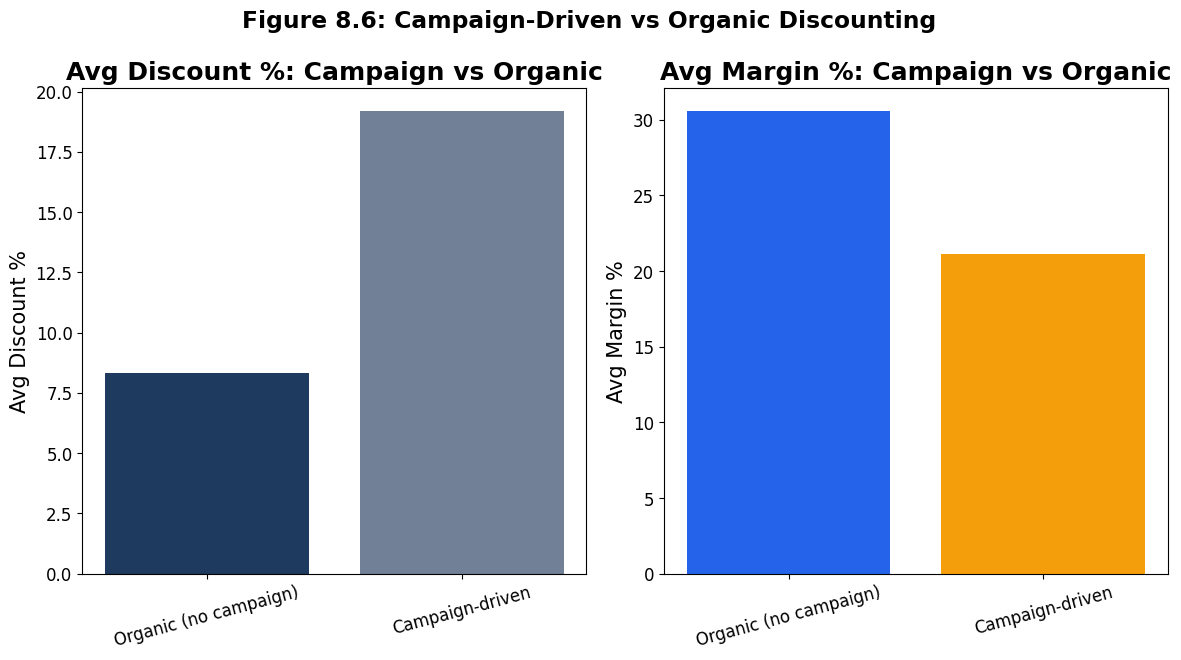

In [56]:
# 5.6 — Campaign / promotion analysis (vs organic)
# =============================================================================
if 'has_campaign' in df.columns:
    campaign_compare = df.groupby('has_campaign').agg(
        transactions=('transaction_id', 'count'),
        avg_discount_pct=('discount_percentage', 'mean'),
        avg_quantity=('quantity', 'mean'),
        total_net_revenue=('net_revenue', 'sum'),
        avg_net_revenue_per_txn=('net_revenue', 'mean'),
        avg_margin_pct=('margin_percentage_tx', 'mean')
    ).round(2)
    campaign_compare.index = campaign_compare.index.map(
        {True: 'Campaign-driven', False: 'Organic (no campaign)'}
    )

    # Define camp_rev here, as it's needed for ROI calculation regardless of campaign cost source
    camp_rev = campaign_compare.loc['Campaign-driven', 'total_net_revenue']

    # Campaign cost (dedupe by campaign_id if present)
    if 'campaign_id' in df.columns and 'campaign_cost' in df.columns:
        total_campaign_cost = (
            df.loc[df['has_campaign'], ['campaign_id', 'campaign_cost']]
            .drop_duplicates('campaign_id')['campaign_cost'].sum()
        )
    elif 'campaign_cost' in df.columns:
        total_campaign_cost = df.loc[df['has_campaign'], 'campaign_cost'].drop_duplicates().sum()
    else:
        total_campaign_cost = np.nan

    campaign_roi_pct = round((camp_rev - total_campaign_cost) / total_campaign_cost * 100, 2) \
        if total_campaign_cost and total_campaign_cost > 0 else None

    # Excessive erosion split
    excessive_by_campaign = (
        excessive.groupby(df.loc[excessive.index, 'has_campaign'])['erosion'].sum()
    )
    excessive_by_campaign.index = excessive_by_campaign.index.map(
        {True: 'Campaign-driven', False: 'Organic (no campaign)'}
    )

    # Hypothesis: campaign margin vs organic margin
    camp_m = df.loc[df['has_campaign'], 'margin_percentage_tx'].dropna()
    org_m = df.loc[~df['has_campaign'], 'margin_percentage_tx'].dropna()
    t_camp, p_camp = stats.ttest_ind(camp_m, org_m, equal_var=False)
    campaign_vs_organic = {
        'comparison': campaign_compare.reset_index().rename(columns={'has_campaign': 'group'}).to_dict(orient='records'),
        'total_campaign_cost': float(total_campaign_cost) if pd.notna(total_campaign_cost) else None,
        'naive_campaign_roi_pct': campaign_roi_pct,
        'roi_caveat': 'Non-causal: does not subtract revenue that would have occurred without the campaign',
        'excessive_erosion_by_group': excessive_by_campaign.round(0).to_dict(),
        'ttest_margin_campaign_vs_organic': {
            't_stat': round(float(t_camp), 4),
            'p_value': round(float(p_camp), 4)
        },
        'generated_at': pd.Timestamp.now('UTC').isoformat()
    }
    save_json(campaign_vs_organic, 'campaign_vs_organic.json')

    print('\n=== Campaign vs Organic ===')
    print(campaign_compare)
    print(f'Total campaign spend: ${total_campaign_cost:,.0f} | Naive ROI: {campaign_roi_pct}%')
    print(f'Excessive erosion split: {dict(excessive_by_campaign.round(0))}')
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
    axes[0].bar(campaign_compare.index, campaign_compare['avg_discount_pct'], color=[NAVY, SLATE])
    axes[0].set_title('Avg Discount %: Campaign vs Organic', fontweight='bold')
    axes[0].set_ylabel('Avg Discount %')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(campaign_compare.index, campaign_compare['avg_margin_pct'], color=[BLUE, AMBER])
    axes[1].set_title('Avg Margin %: Campaign vs Organic', fontweight='bold')
    axes[1].set_ylabel('Avg Margin %')
    axes[1].tick_params(axis='x', rotation=15)

    fig.suptitle('Figure 8.6: Campaign-Driven vs Organic Discounting', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'campaign_vs_organic.png')
    plt.show()
else:
    print('Column has_campaign not found — skipping campaign analysis')

In [57]:
#Module summary (for report Section 8)
# =============================================================================
print('\n' + '=' * 60)
print('MODULE 4 KEY NUMBERS FOR SECTION 8')
print('=' * 60)
print(f"Average discount: {discount_kpis['avg_discount_pct']}% "
      f"({discount_kpis['pct_transactions_discounted']}% of txns discounted)")
print(f"Price elasticity β: {elasticity_result['elasticity_coef']} "
      f"(p={elasticity_result['elasticity_pvalue']}) — {elasticity_result['interpretation']}")
print(f"Corr(discount, quantity): {corr_discount_qty:.4f}")
print(f"Corr(discount, margin): {corr_discount_margin:.4f}")
print(f"Revenue erosion (>20% discounts): ${total_erosion:,.0f} "
      f"({erosion_summary['erosion_as_pct_of_total_net_revenue']}% of net revenue)")
if len(erosion_by_category):
    print(f"Category with highest erosion: {erosion_by_category.index[0]} "
          f"(${erosion_by_category.iloc[0]:,.0f})")
print(f"Over-discounted products flagged: {len(over_disc_products)}")
print(f"Over-discounted customers flagged: {len(over_disc_customers)}")
print('\nRevenue by discount band (total net revenue):')
print(rev_by_band[['total_net_revenue', 'revenue_share_pct', 'avg_margin_pct']])


MODULE 4 KEY NUMBERS FOR SECTION 8
Average discount: 10.45% (77.18% of txns discounted)
Price elasticity β: 0.0019 (p=0.3869) — Inelastic / not significant
Corr(discount, quantity): -0.0020
Corr(discount, margin): -0.5529
Revenue erosion (>20% discounts): $633,668 (3.5% of net revenue)
Category with highest erosion: Electronics ($206,223)
Over-discounted products flagged: 0
Over-discounted customers flagged: 24

Revenue by discount band (total net revenue):
               total_net_revenue  revenue_share_pct  avg_margin_pct
discount_band                                                      
0%                    4520159.36              24.95           36.83
1-5%                  3779474.54              20.87           33.61
11-15%                2814601.34              15.54           26.35
16-20%                2023482.24              11.17           22.09
20%+                  1614675.05               8.91           11.79
6-10%                 3361409.11              18.56          